In [1]:
%matplotlib inline
%load_ext line_profiler
import  multiprocessing
    
import pandas as pd
import numpy as np

import mplfinance as mpl 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from trading import trade, portfolio_value
from strategies import mean_reverting

def ceil(n, d):
    return -(n // -d)

db password ········


In [3]:
from database_query import get_price_data, get_symbols_with_pd

In [4]:
master = get_price_data(get_symbols_with_pd(), date_range='2024-1-27::2025-1-28', default_cols=['close'])
master.close = master.close.astype('float64')
master.set_index('price_date', inplace=True)

master = master.pivot(columns=['ticker']).dropna()
#master

In [6]:
def test(pairs):
    s1,s2 = pairs
    ####SETUP####
    #Portfolio and Strategy
    start_money, max_trade_perc = 1000, 0.1
    portfolio = {'money':start_money, 'max_trade':start_money*max_trade_perc, 'stocks':{}, 'b_count':0, 's_count':0, 'val_hist':[start_money]}
    
    order_book = mean_reverting(master, s1,s2)
    
    for date, order in order_book:   
        portfolio = trade(order, portfolio)
        #if track_value:
            #portfolio['val_hist'].append(portfolio_value(portfolio, master.loc[date].close)['Total'])
        
    res[f'{s1},{s2}'] = (portfolio, portfolio_value(portfolio, master.loc[date].close))  
    res_table.loc[s1,s2] = res[f'{s1},{s2}'][1]['Total']


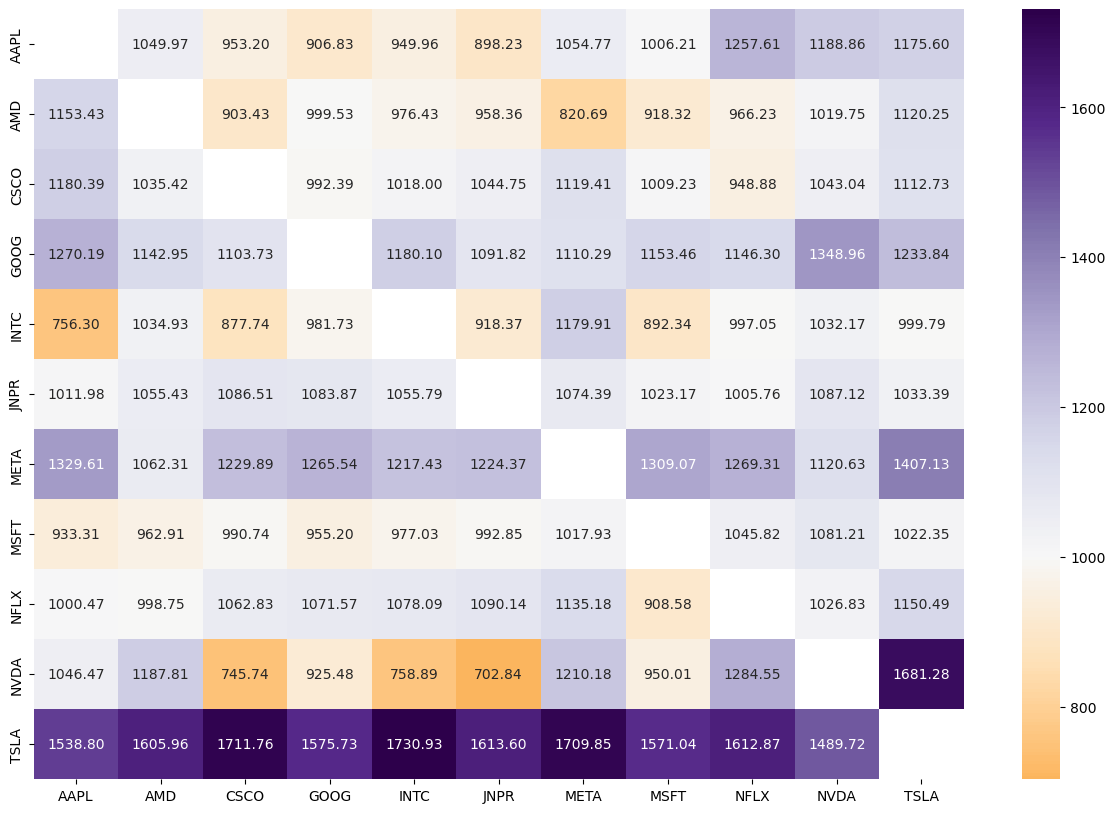

CPU times: total: 1.33 s
Wall time: 6.54 s


In [9]:
%%time
from joblib import parallel_config
from joblib import Parallel, delayed

tickers = ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA']
pairs = [(x,y) for x in tickers for y in tickers if x!=y]
track_value = False
res = {}
res_table = pd.DataFrame(columns=tickers, index=tickers)

with parallel_config(backend='threading', n_jobs=3, require='sharedmem'):
   out = Parallel()(delayed(test)(pair) for pair in pairs)
    
res_table = res_table.astype('float')
plt.figure(figsize=(15,10))
sns.heatmap(res_table, annot=True, fmt=".2f", cmap='PuOr', center=1000)
plt.show()

In [ ]:
if track_value:
    fig, axes = plt.subplots(nrows=ceil(len(tickers),2), ncols=2, figsize=(15,25) )
    i, j = -1, True
    
    for s1 in tickers:
        
    +=1    if j == True:
            i 
        j = not(j)
        
    tickers:
            if s1 == s2:
                continue    for s2 in 
            
            stock_combo = f'{s1},{s2}'
    axes[i][int(j)].plot(res[stock_combo][0]['val_hist'], label = stock_combo)
            
        axes[i][int(j)].legend(loc='lower left')
    
        
    plt.show()        